# Setup and Scale Cuts

Combine calculations for converting physical scales (Mpc/h) into angular scales ($\theta_{FWHM}$) and estimating the resulting noise levels when smoothing the full sky maps.


In [1]:
import os, h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import healpy as hp

from msfm.utils import files, redshift, clustering, scales
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

os.environ["OMP_NUM_THREADS"] = str(len(os.sched_getaffinity(0)))

def rad_to_arcmin(theta):
    return theta / np.pi * 180 * 60


In [2]:
# Pre-calculate angular scales for varying Mpc/h inputs
mpcs = [
    (4, 16),
    (6, 20),
    (8, 24),
    (10, 28),
    (12, 32),
    (14, 36),
    (16, 40),
]

thresholds = [
    0.01,
]


## 1. Parameters & Cosmology
Load the configuration and cosmology to map physical comoving scales to angular sizes for given redshift bins.

In [3]:
conf_path = "/users/athomsen/dlss/repos/multiprobe-simulation-forward-model/configs/v16/default.yaml"
conf = files.load_config(conf_path)

# Cosmology Setup
fid_cosmo = FlatLambdaCDM(
    Om0=conf["analysis"]["fiducial"]["Om"],
    Ob0=conf["analysis"]["fiducial"]["Ob"],
    H0=conf["analysis"]["fiducial"]["H0"],
    Tcmb0=2.7255,
    Neff=3.046,
    m_nu=0.02 * u.eV,
)

h = conf["analysis"]["fiducial"]["H0"] / 100

# Bin Setup 
metacal_bins = conf["survey"]["metacal"]["z_bins"]
maglim_bins = conf["survey"]["maglim"]["z_bins"]

tomo_z_metacal, tomo_nz_metacal = files.load_redshift_distributions("metacal", conf)
tomo_z_maglim, tomo_nz_maglim = files.load_redshift_distributions("maglim", conf)

z_bar_metacal = [np.sum(z * nz) for z, nz in zip(tomo_z_metacal, tomo_nz_metacal)]
z_bar_maglim = [np.sum(z * nz) for z, nz in zip(tomo_z_maglim, tomo_nz_maglim)]


theta_fwhms = []
for mpc_metacal, mpc_maglim in mpcs:
    R_c_metacal = mpc_metacal * u.Mpc / h
    theta_metacal = R_c_metacal / fid_cosmo.comoving_distance(z_bar_metacal)
    
    R_c_maglim = mpc_maglim * u.Mpc / h
    theta_maglim = R_c_maglim / fid_cosmo.comoving_distance(z_bar_maglim)
    
    theta_fwhms.append(list(rad_to_arcmin(theta_metacal.value)) + list(rad_to_arcmin(theta_maglim.value)))


## 2. Load Sky Maps
Set up global parameters for map evaluations and load the fiducial projected map sets for smoothing.

In [4]:
n_side = conf["analysis"]["n_side"]
n_pix = conf["analysis"]["n_pix"]
l_min_global = 30
l_max_global = 1535
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"
hp_datapath = "/users/athomsen/dlss/repos/multiprobe-simulation-forward-model/data/healpy_data"

n_z_metacal = len(metacal_bins)
n_z_maglim = len(maglim_bins)
n_z = n_z_metacal + n_z_maglim

# fiducial values
z0 = conf["survey"]["metacal"]["z0"]
Aia = conf["analysis"]["fiducial"]["Aia"]
n_Aia = conf["analysis"]["fiducial"]["n_Aia"]
tomo_Aia = redshift.get_tomo_amplitudes(Aia, n_Aia, tomo_z_metacal, tomo_nz_metacal, z0)

tomo_bg = [conf["analysis"]["fiducial"][f"bg{i+1}"] for i in range(n_z_maglim)]
tomo_n_gal_maglim = np.array(conf["survey"]["maglim"]["n_gal"]) * hp.nside2pixarea(n_side, degrees=True)


In [5]:
%%time
# fidu_dir = "/global/cfs/cdirs/des/cosmogrid/processed/v11desy3/CosmoGrid/bary/fiducial/cosmo_fiducial"
fidu_dir = "/users/athomsen/scratch/deep_lss/data/projected/fiducial/cosmo_fiducial"

n_examples = 10

wl = []
gc = []
for i in tqdm(range(n_examples)):
    with h5py.File(os.path.join(fidu_dir, f"perm_{i:04d}", "projected_probes_maps_v11dmb.h5"), "r") as f:
        kg = []
        ia = []
        for z_bin in metacal_bins:
            kg.append(hp.ud_grade(f[f"map/kg/{z_bin}"], n_side))
            ia.append(hp.ud_grade(f[f"map/ia/{z_bin}"], n_side))
        kg = np.stack(kg, axis=-1)
        ia = np.stack(ia, axis=-1)
        
        wl.append(kg + tomo_Aia * ia)

        dg = []
        for z_bin in maglim_bins:
            dg.append(hp.ud_grade(f[f"map/dg/{z_bin}"], n_side))
        dg = np.stack(dg, axis=-1)
        
        gc.append(clustering.galaxy_density_to_count(tomo_n_gal_maglim, (dg - np.mean(dg))/np.mean(dg), tomo_bg))

wl = np.stack(wl, axis=0)
gc = np.stack(gc, axis=0)

fidu_maps = np.concatenate([wl, gc], axis=-1)

print(fidu_maps.shape)


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [04:48<00:00, 28.89s/it]


(10, 3145728, 8)
CPU times: user 4min 29s, sys: 20.4 s, total: 4min 49s
Wall time: 4min 49s


## 3. Scale Cut Definitions & Noise Matching
Compute power spectra $\ell$ suppression factors and correlate them back to an equivalent $\sigma$ for white Gaussian noise.

In [6]:
raw_cls = np.zeros((n_examples, l_max_global+1, n_z))
for i, fidu_map in enumerate(fidu_maps):
    for j in range(fidu_map.shape[-1]):
        raw_cls[i,:,j] = hp.anafast(fidu_map[:,j], lmax=l_max_global, pol=False, datapath=hp_datapath, use_pixel_weights=True)
        
mean_cls = np.mean(raw_cls, axis=0)
smooth_cls = np.zeros_like(mean_cls)
l = np.arange(0, l_max_global+1)

with np.printoptions(precision=4, suppress=False, formatter={'float': '{:0.4e}'.format}):
    for (mpc_metacal, mpc_maglim), fwhm in zip(mpcs, theta_fwhms):
        print(f"\nmpc/h = {(mpc_metacal, mpc_maglim)}")
        print(f"theta_fwhm = {fwhm}")
        l_maxs_naive = list(scales.angle_to_ell(np.array(fwhm), arcmin=True).astype(int))
        
        for threshold in thresholds:
            l_maxs_thresh = []
            cl_noise_levels = []
            sigmas = []
            sigmas_naive = []
            for i in range(len(fwhm)):
                # smoothing
                high_pass_fac_cls = scales.gaussian_high_pass_factor_alm(l, l_min=30)**2
                low_pass_fac_cls = scales.gaussian_low_pass_factor_alm(l, theta_fwhm=fwhm[i], arcmin=True)**2
                smooth_cls[:,i] = high_pass_fac_cls * low_pass_fac_cls * mean_cls[:,i]

                # determine the l_max when the Cls are suppressed by as much as the threshold
                try:
                    l_max = l[low_pass_fac_cls < threshold][0]
                except IndexError:
                    l_max = l_max_global
                l_maxs_thresh.append(l_max)

                # evaluate the full sky Cls at that l_max 
                cl_noise_level = smooth_cls[l_max,i]
                cl_noise_levels.append(cl_noise_level)

                # convert to a sigma of white Gaussian noise
                sigma = np.sqrt(cl_noise_level / hp.nside2pixarea(n_side))
                sigmas.append(sigma)

            l_maxs_thresh = np.array(l_maxs_thresh)
            cl_noise_levels = np.array(cl_noise_levels)
            sigmas = np.array(sigmas)

            print(f"\nthreshold = {threshold*100}%")
            # print(f"l_maxs_naive = {np.array(l_maxs_naive)}")
            print(f"l_maxs_thresh = {l_maxs_thresh}")
            # print(f"cl_noise_levels = {cl_noise_levels}")
            print(f"sigmas = {sigmas}")

        # print(f"\nthreshold = naive")
        # print(f"l_maxs_naive = {np.array(l_maxs_naive)}")


mpc/h = (4, 16)
theta_fwhm = [np.float64(14.755824470069935), np.float64(10.065563880771993), np.float64(7.493930095637529), np.float64(6.287388209356527), np.float64(65.10123531798226), np.float64(44.45232206711141), np.float64(34.0619154835116), np.float64(28.52162382389204)]

threshold = 1.0%
l_maxs_thresh = [1177 1535 1535 1535  267  391  510  609]
sigmas = [1.5454e-04 3.8853e-04 1.4364e-03 2.3850e-03 6.0252e-01 2.6137e-01
 2.4737e-01 2.5931e-01]

mpc/h = (6, 20)
theta_fwhm = [np.float64(22.1337367051049), np.float64(15.09834582115799), np.float64(11.240895143456296), np.float64(9.431082314034791), np.float64(81.37654414747782), np.float64(55.56540258388926), np.float64(42.5773943543895), np.float64(35.652029779865046)]

threshold = 1.0%
l_maxs_thresh = [ 785 1151 1535 1535  213  313  408  487]
sigmas = [2.3739e-04 3.0936e-04 4.0631e-04 9.8050e-04 7.0164e-01 3.0908e-01
 2.9662e-01 3.0670e-01]

mpc/h = (8, 24)
theta_fwhm = [np.float64(29.51164894013987), np.float64(20.1311277615439

## 4. Evaluate Power Spectra & Visualise
Plot power spectrum distributions matching our defined cuts for lensing and clustering observables.

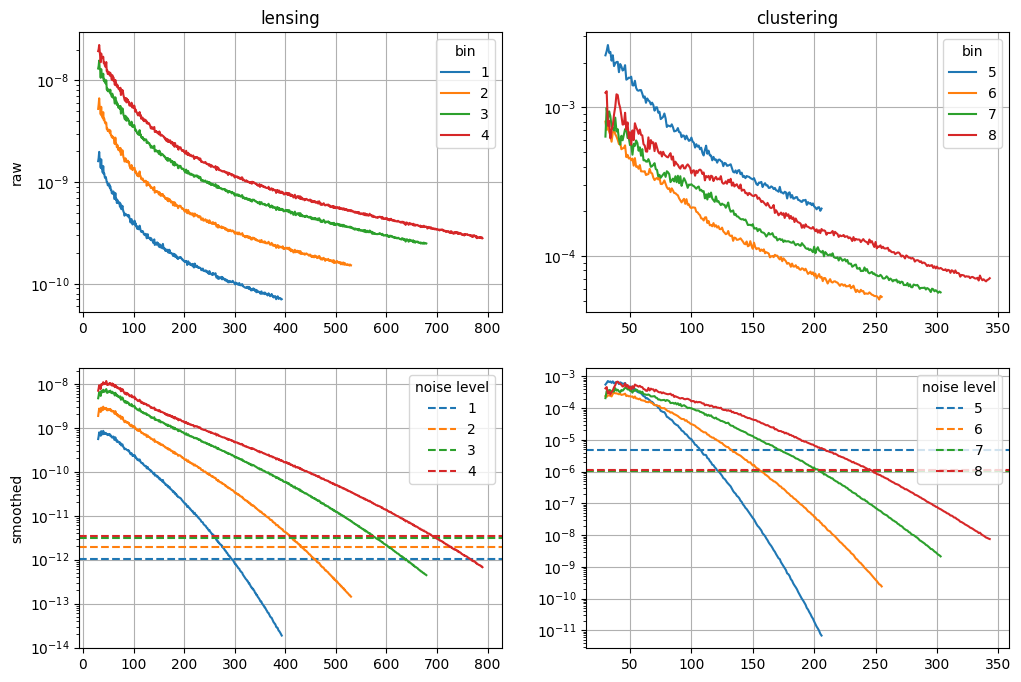

In [7]:
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2, sharex=False, sharey=False)
# colors = sns.color_palette("hls", n_z)
colors = sns.color_palette("tab10", 4)

for i in range(n_z):
    j = 0 if i < n_z_metacal else 1
    l_max = l_maxs_thresh[i]
    l_max_plot = min(l_max + 100, l_max_global)
    l_plot = np.arange(l_min_global, l_max_plot)

    ax[0,j].plot(l_plot, mean_cls[l_min_global:l_max_plot,i], label=i+1, color=colors[i%4])
    ax[1,j].plot(l_plot, smooth_cls[l_min_global:l_max_plot,i], color=colors[i%4])
    ax[1,j].axhline(cl_noise_levels[i], linestyle="--", label=i+1, color=colors[i%4])

for i in range(2):
    for j in range(2):
        ax[i,j].grid(True)
        ax[i,j].set(xscale="linear", yscale="log")
    
ax[0,0].set(title="lensing", ylabel="raw")
ax[1,0].set(ylabel="smoothed")
ax[0,1].set(title="clustering")

ax[0,0].legend(loc="upper right", title="bin")
ax[0,1].legend(loc="upper right", title="bin")

ax[1,0].legend(loc="upper right", title="noise level")
ax[1,1].legend(loc="upper right", title="noise level")

os.makedirs("plots", exist_ok=True)
fig.savefig(f"plots/cl_noise_level_1_threshold={threshold}.png", bbox_inches="tight", dpi=100)


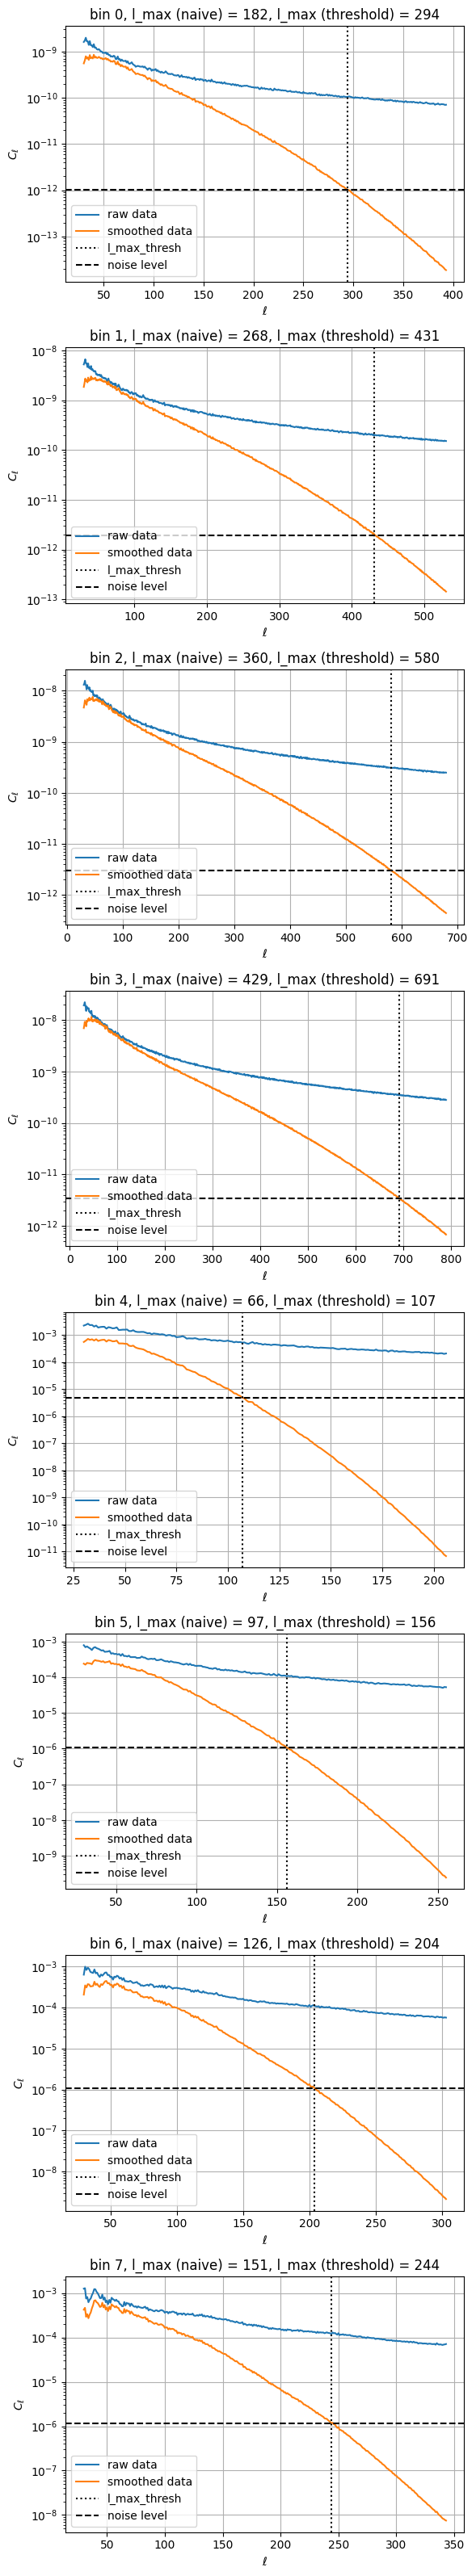

In [8]:
fig, ax = plt.subplots(figsize=(6, 4*n_z), nrows=n_z, sharex=False, sharey=False)

for i in range(n_z):
    l_max = l_maxs_thresh[i]
    l_max_plot = min(l_max + 100, l_max_global)
    l_plot = np.arange(l_min_global, l_max_plot)
        
    ax[i].plot(l_plot, mean_cls[l_min_global:l_max_plot,i], label="raw data")
    ax[i].plot(l_plot, smooth_cls[l_min_global:l_max_plot,i], label="smoothed data")
    ax[i].axvline(l_maxs_thresh[i], color="k", linestyle=":", label="l_max_thresh")
    ax[i].axhline(cl_noise_levels[i], color="k", linestyle="--", label="noise level")
        
    ax[i].set(
        xscale="linear", 
        yscale="log", 
        title=f"bin {i}, l_max (naive) = {l_maxs_naive[i]}, l_max (threshold) = {l_max}", 
        xlabel=r"$\ell$", 
        ylabel=r"$C_\ell$",
    )
    ax[i].grid(True)
    ax[i].legend(loc="lower left")
    
fig.tight_layout()
fig.savefig(f"plots/cl_noise_level_2_threshold={threshold}.png", bbox_inches="tight", dpi=100)


### 4.1 Validate White Noise Levels Against Thresholds

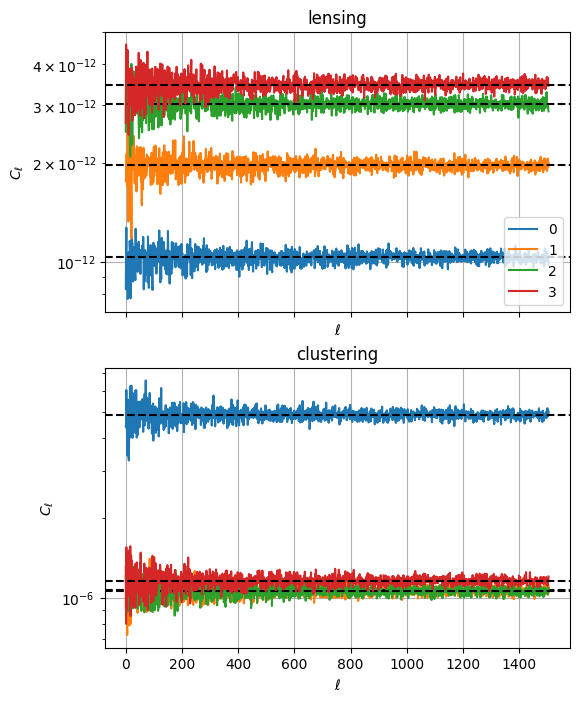

In [9]:
fig, ax = plt.subplots(figsize=(6,4*2), nrows=2, sharex=True)

rng = np.random.default_rng()
for i, sigma in enumerate(sigmas):
    noise_map = rng.normal(size=n_pix, loc=0, scale=sigma)
    noise_cls = hp.anafast(noise_map, lmax=l_max_global, pol=False, datapath=hp_datapath, use_pixel_weights=True)
    
    j = 0 if i<n_z_metacal else 1
    ax[j].plot(noise_cls[l_min_global:l_max_global], label=i)
    ax[j].axhline(cl_noise_levels[i], color="k", linestyle="--")

for i in range(2):
    ax[i].set(xscale="linear", yscale="log", xlabel=r"$\ell$", ylabel=r"$C_\ell$")
    ax[i].grid(True)
    
ax[0].set(title="lensing")
ax[1].set(title="clustering")
ax[0].legend(loc="best")